<a href="https://colab.research.google.com/github/hyphen-ani/Deep-Learning-Pytorch/blob/main/Vector_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
sentences = [
    "Hey, This is an example for generating Vector Embeddings For Under Standing The Code behind Vector Embeddings"
]

In [ ]:
embeddings = model.encode(sentences=sentences)

In [ ]:
for i, embeddings in enumerate(embeddings):
  print(f"Sentence {i}: {embeddings[:10]}")

Sentence 0: [-0.19115084 -0.075465    0.0860647   0.12860288  0.08613166 -0.05383195
  0.01740566  0.1515275  -0.0722741   0.04378127]


In [ ]:
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
sentence = "Hey, This is an example for generating Vector Embeddings For Under Standing The Code behind Vector Embeddings, Wisemelon is transforming chatbot experiences."

In [ ]:
token_emb_output = model.tokenize([sentence])
with torch.no_grad():
  model_output = model._first_module()(token_emb_output)

In [ ]:
token_embeddings = model_output['token_embeddings']
tokens = model.tokenizer.convert_ids_to_tokens(token_emb_output['input_ids'][0])

In [ ]:
pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(token_embeddings[0])

In [ ]:
attention_mask = token_emb_output['attention_mask']
input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
mean_embeddings = sum_embeddings / sum_mask

In [ ]:
print("Token Embeddings Shape : ", token_embeddings.shape)
print("Mean Embeddings Shape : ", mean_embeddings.shape)

Token Embeddings Shape :  torch.Size([1, 41, 384])
Mean Embeddings Shape :  torch.Size([1, 384])


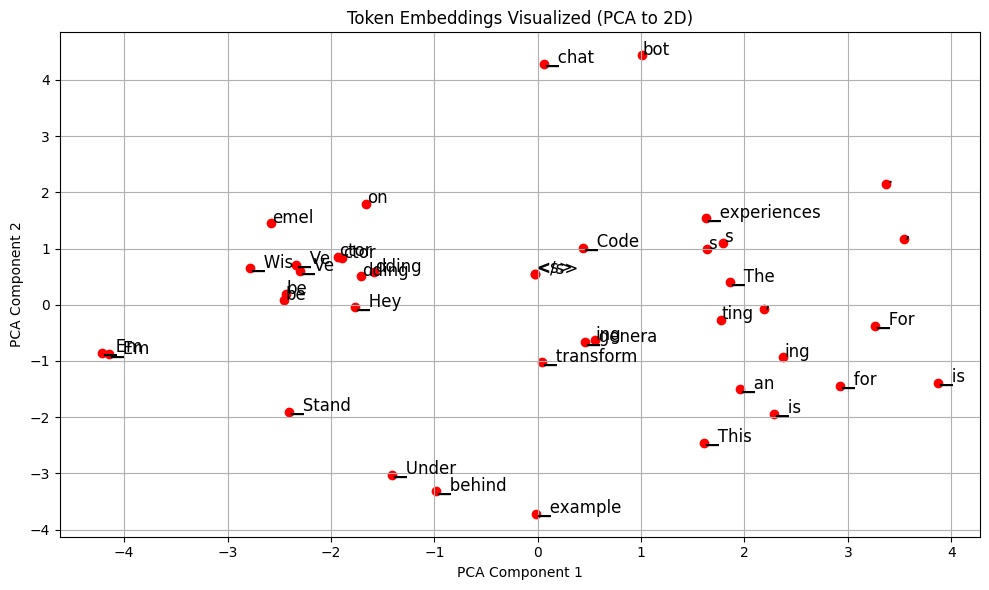

In [ ]:
plt.figure(figsize=(10, 6))
for token, (x, y) in zip(tokens, reduced_embeddings):
    plt.scatter(x, y, color='red')
    plt.text(x + 0.01, y + 0.01, token, fontsize=12)

plt.title("Token Embeddings Visualized (PCA to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

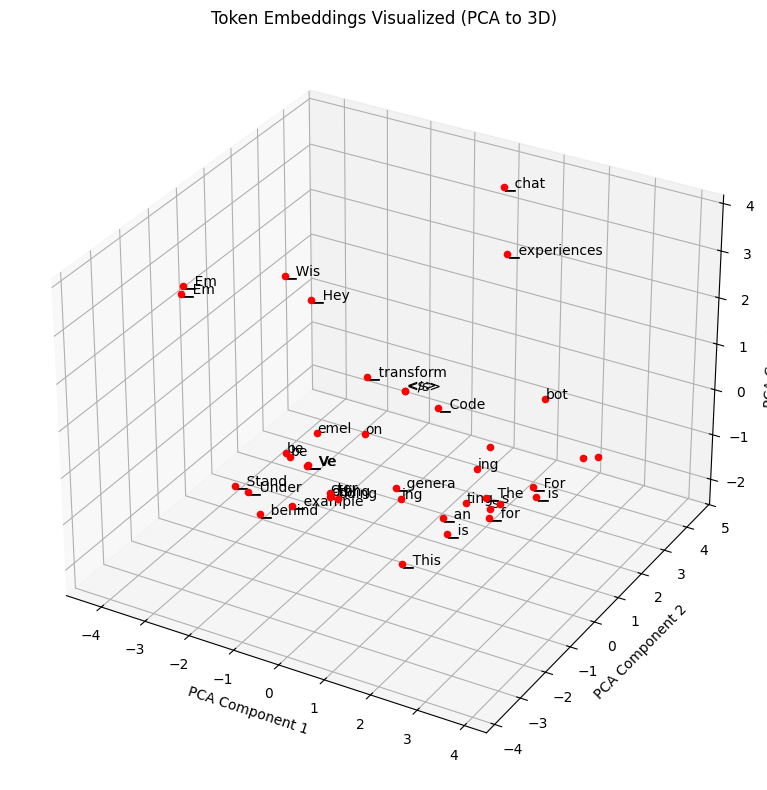

In [ ]:
pca = PCA(n_components=3)
reduced_embeddings_3d = pca.fit_transform(token_embeddings[0])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for token, (x, y, z) in zip(tokens, reduced_embeddings_3d):
    ax.scatter(x, y, z, color='red')
    ax.text(x + 0.01, y + 0.01, z + 0.01, token, fontsize=10)

ax.set_title("Token Embeddings Visualized (PCA to 3D)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

plt.tight_layout()
plt.show()